<a href="https://colab.research.google.com/github/Ayush-0918/Machine-learning/blob/main/Incurence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


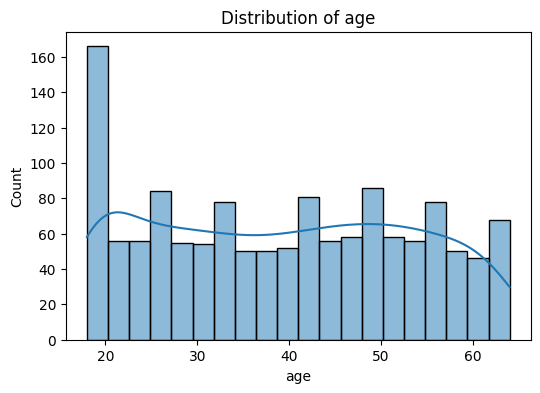

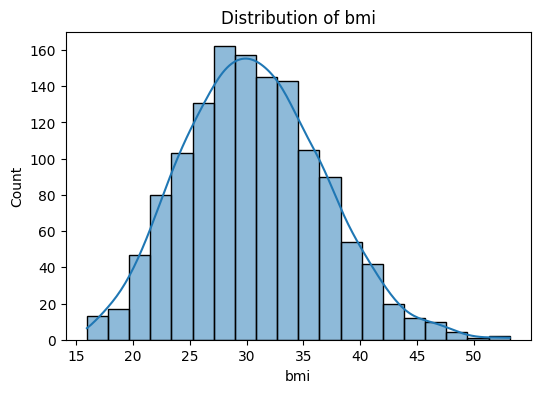

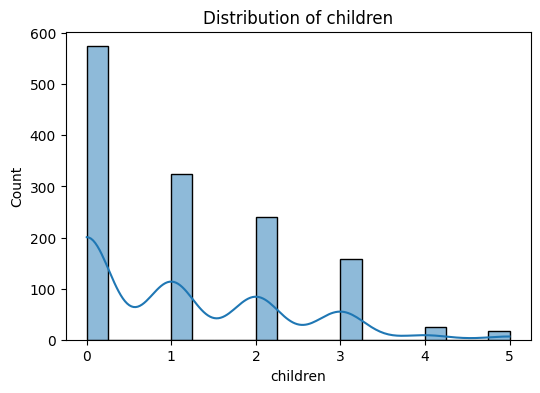

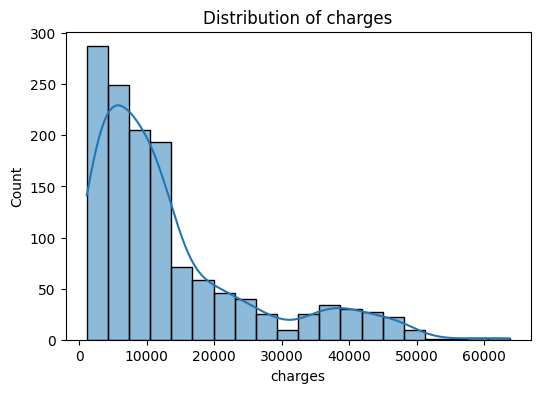

In [9]:
numeric_columns = ['age', 'bmi', 'children', 'charges']

for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

<Axes: xlabel='children', ylabel='count'>

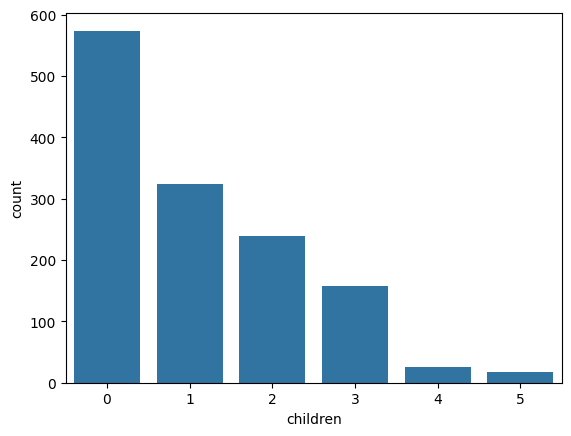

In [10]:
sns.countplot(x= df['children'])

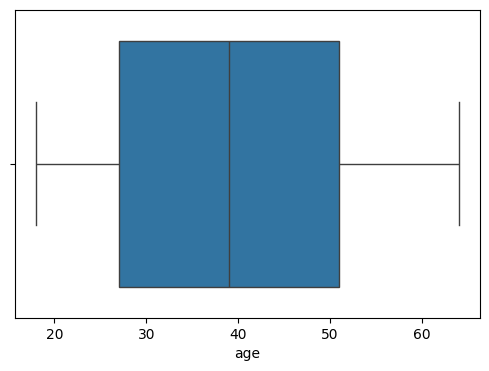

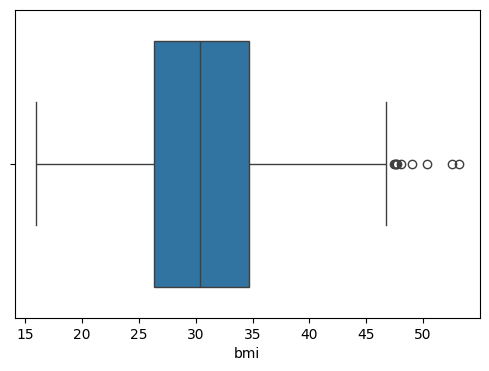

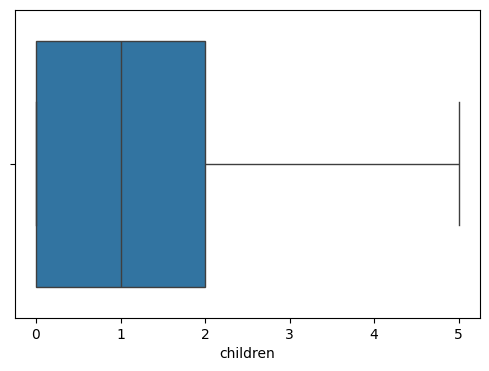

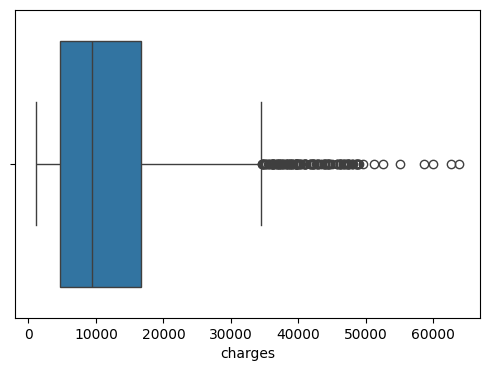

In [11]:
for col in numeric_columns:
   plt.figure(figsize=(6,4))
   sns.boxplot(x=df[col])

<Axes: >

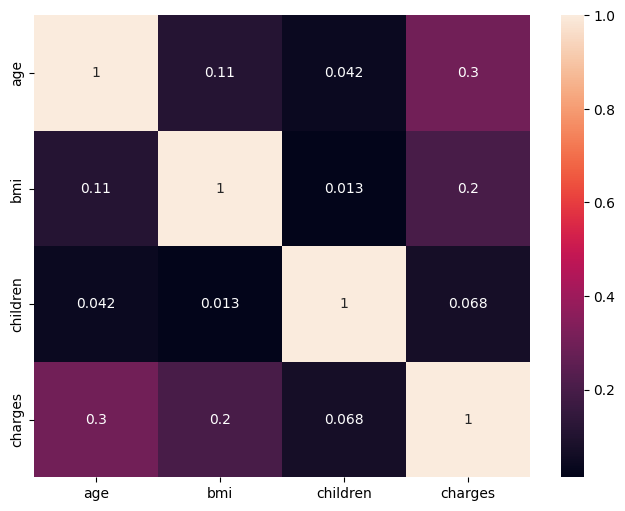

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

#Data Cleaning and Data Pre-Processing

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(1337, 7)

#Label Encoding

In [15]:
df['sex'] = df['sex'].map({'male':0 ,'female':1})

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [17]:
df['smoker'] = df['smoker'].map({'yes':0 ,'no':1})

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520


#One Hot Encoding

In [19]:
df=pd.get_dummies(df,columns=['region'],drop_first=True)

In [20]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,0,16884.92400,False,False,True
1,18,0,33.770,1,1,1725.55230,False,True,False
2,28,0,33.000,3,1,4449.46200,False,True,False
3,33,0,22.705,0,1,21984.47061,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False


In [21]:
df = df.astype(int)

In [22]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,0,16884,0,0,1
1,18,0,33,1,1,1725,0,1,0
2,28,0,33,3,1,4449,0,1,0
3,33,0,22,0,1,21984,1,0,0
4,32,0,28,0,1,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0
1334,18,1,31,0,1,2205,0,0,0
1335,18,1,36,0,1,1629,0,1,0
1336,21,1,25,0,1,2007,0,0,1


#Feature Engineering and Extraction

In [24]:
df['bmi_category'] = pd.cut(

    df['bmi'],

    bins=[0, 18.5, 24.9, 29.9, float('inf')],

    labels=['Underweight', 'Normal', 'Overweight', 'Obese']

)

In [26]:
df = pd.get_dummies(df,columns = ['bmi_category'],drop_first=True)


In [27]:
df = df.astype(int)

In [28]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,0,16884,0,0,1,0,1,0
1,18,0,33,1,1,1725,0,1,0,0,0,1
2,28,0,33,3,1,4449,0,1,0,0,0,1
3,33,0,22,0,1,21984,1,0,0,1,0,0
4,32,0,28,0,1,3866,1,0,0,0,1,0


In [29]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

In [34]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df[feature], df['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
0,age,0.298309
10,bmi_category_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,sex,-0.058046
8,bmi_category_Normal,-0.104042
9,bmi_category_Overweight,-0.120601


In [36]:
cat_features = [
    'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [37]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df['charges_bin'] = pd.qcut(df['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df[col], df['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
sex,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [40]:
final_df = df[['age', 'sex', 'bmi', 'children', 'smoker', 'charges','region_southeast','bmi_category_Obese']]


In [41]:
final_df

,age,sex,bmi,children,smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,0,16884,0,0
1,-1.511647,0,0.462463,-0.079442,1,1725,1,1
2,-0.799350,0,0.462463,1.580143,1,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,1,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,1,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,1,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,1,2007,0,0
